In [3]:
import os
import random
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# Создаем нужные директории, если их нет
os.makedirs('artifacts/figures', exist_ok=True)

# 1. Фиксация seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

# 2. Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


Число наблюдений: 4320
Диапазон дат: от 2025-01-01 00:00:00 до 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64


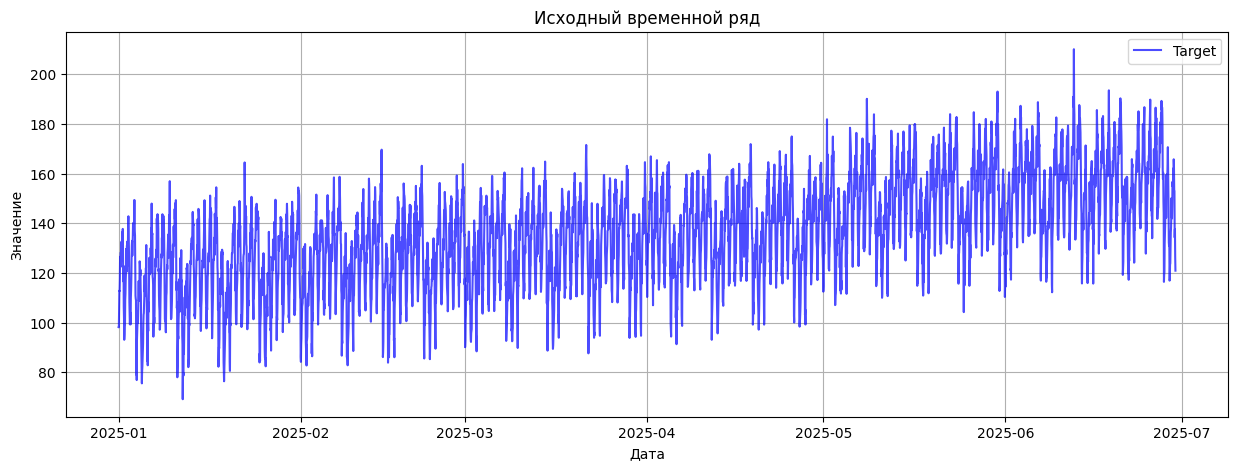

In [4]:
# 1. Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')

# 2. Приведение к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 3. Базовая статистика
print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: от {df['date'].min()} до {df['date'].max()}")
print("Пропуски по колонкам:")
print(df.isna().sum())

# Обработка пропусков: если они есть, интерполируем линейно, так как это временной ряд
if df.isna().any().any():
    df['target'] = df['target'].interpolate(method='linear')
    print("Пропуски заполнены линейной интерполяцией.")

# 4. Базовый график
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['target'], label='Target', color='blue', alpha=0.7)
plt.title('Исходный временной ряд')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

# КОММЕНТАРИЙ (для отчета): Ряд имеет ярко выраженную суточную сезонность (данные по часам)
# и возможные локальные тренды.

Train границы: 2025-01-01 00:00:00 - 2025-05-06 23:00:00
Val границы: 2025-05-07 00:00:00 - 2025-06-02 23:00:00
Test границы: 2025-06-03 00:00:00 - 2025-06-29 23:00:00


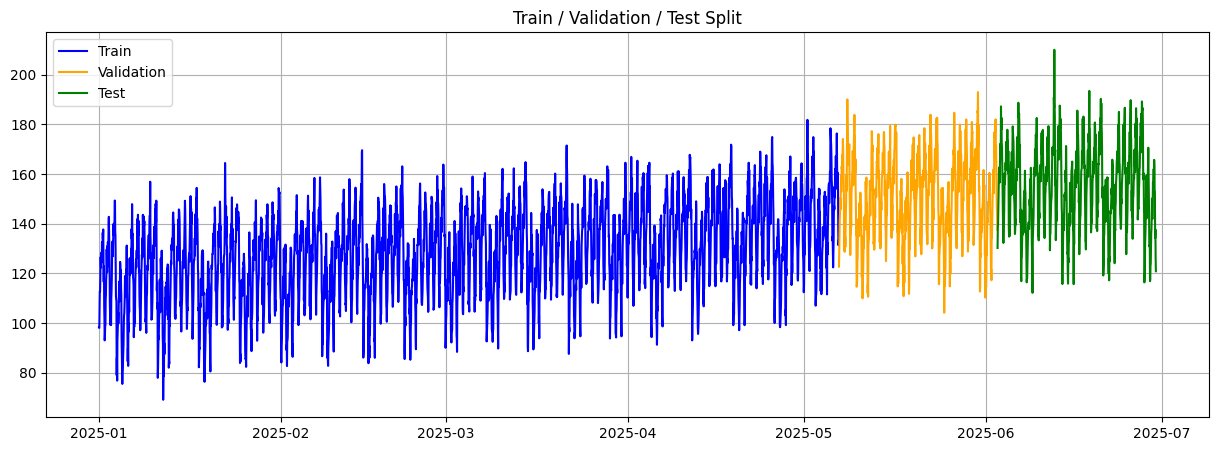

In [5]:
# 1. Разбиение по времени (70% train, 15% val, 15% test)
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f"Train границы: {train_df['date'].min()} - {train_df['date'].max()}")
print(f"Val границы: {val_df['date'].min()} - {val_df['date'].max()}")
print(f"Test границы: {test_df['date'].min()} - {test_df['date'].max()}")

# 3. Визуализация разбиения
plt.figure(figsize=(15, 5))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.title('Train / Validation / Test Split')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/series_split.png', bbox_inches='tight')
plt.show()

# ПОЧЕМУ RANDOM SPLIT НЕКОРРЕКТЕН:
# Случайное разбиение (random split) приведет к тому, что в обучающую выборку попадут данные
# из будущего по отношению к валидационной выборке. Это вызовет "утечку данных" (data leakage),
# и модель просто выучит значения соседних точек, показав нереалистично высокое качество,
# но будет бесполезна на реальных будущих данных.

In [6]:
def create_features(data):
    d = data.copy()

    # Лаговые признаки
    d['lag_1'] = d['target'].shift(1)
    d['lag_7'] = d['target'].shift(7)
    d['lag_14'] = d['target'].shift(14)

    # Rolling признаки (окно считается по ПРЕДЫДУЩИМ значениям, чтобы не было заглядывания в будущее)
    d['rolling_mean_7'] = d['lag_1'].rolling(window=7).mean()
    d['rolling_std_7'] = d['lag_1'].rolling(window=7).std()

    # Календарные признаки
    d['dayofweek'] = d['date'].dt.dayofweek
    d['hour'] = d['date'].dt.hour

    return d

# Создаем фичи для всего датасета, чтобы лаги на границах train/val/test перетекали корректно
df_features = create_features(df)

# Снова бьем на train/val/test по тем же индексам
train_feat = df_features.iloc[:train_size].dropna() # Дропаем NaN от лагов только в начале train
val_feat = df_features.iloc[train_size:train_size + val_size]
test_feat = df_features.iloc[train_size + val_size:]

features_list = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']

X_train, y_train = train_feat[features_list], train_feat['target']
X_val, y_val = val_feat[features_list], val_feat['target']
X_test, y_test = test_feat[features_list], test_feat['target']

# Масштабирование обучаем ТОЛЬКО на train
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

In [7]:
WINDOW_SIZE = 24

class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(1), torch.tensor(y, dtype=torch.float32)

# Скейлим таргет для нейросети
target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_df[['target']]).flatten()
val_target_scaled = target_scaler.transform(val_df[['target']]).flatten()
test_target_scaled = target_scaler.transform(test_df[['target']]).flatten()

train_dataset = TimeSeriesDataset(train_target_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(val_target_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(test_target_scaled, WINDOW_SIZE)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) # shuffle=False для ВР!
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(GRUForecaster, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :]) # Берем только последний скрытый слой
        return out

def eval_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mean_absolute_percentage_error(y_true, y_pred)
    }

runs_results = []

In [12]:
# --- B1: Naive Last ---
# Предсказываем значением предыдущего часа
val_b1_pred = val_feat['lag_1']
metrics_b1 = eval_metrics(y_val, val_b1_pred)

runs_results.append({
    'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12', 'seed': SEED,
    'split_summary': '70/15/15', 'window_size': 1, 'horizon': 1,
    'model_summary': 'naive-last', 'notes': 'Predicts with the value of the previous hour.', 'best_val_mae': metrics_b1['mae'],
    'best_val_rmse': metrics_b1['rmse'], 'best_val_mape': metrics_b1['mape']
})

# --- B2: Moving Average ---
# Предсказываем скользящим средним за последние 7 часов
val_b2_pred = val_feat['rolling_mean_7']
# Заполним возможные NaN первым доступным
val_b2_pred = val_b2_pred.fillna(method='bfill')
metrics_b2 = eval_metrics(y_val, val_b2_pred)

runs_results.append({
    'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12', 'seed': SEED,
    'split_summary': '70/15/15', 'window_size': 7, 'horizon': 1,
    'model_summary': 'moving-average', 'notes': 'Predicts with the rolling mean over the last 7 hours.', 'best_val_mae': metrics_b2['mae'],
    'best_val_rmse': metrics_b2['rmse'], 'best_val_mape': metrics_b2['mape']
})

# --- B3: Ridge ---
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
val_b3_pred = ridge.predict(X_val_scaled)
metrics_b3 = eval_metrics(y_val, val_b3_pred)

runs_results.append({
    'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12', 'seed': SEED,
    'split_summary': '70/15/15', 'window_size': 14, 'horizon': 1,
    'model_summary': 'ridge-lag-features', 'features_summary': 'lags 1,7,14, roll mean/std 7, dayofweek, hour',
    'scaler': 'StandardScaler', 'notes': 'Ridge regression with lag and calendar features.', 'best_val_mae': metrics_b3['mae'],
    'best_val_rmse': metrics_b3['rmse'], 'best_val_mape': metrics_b3['mape']
})

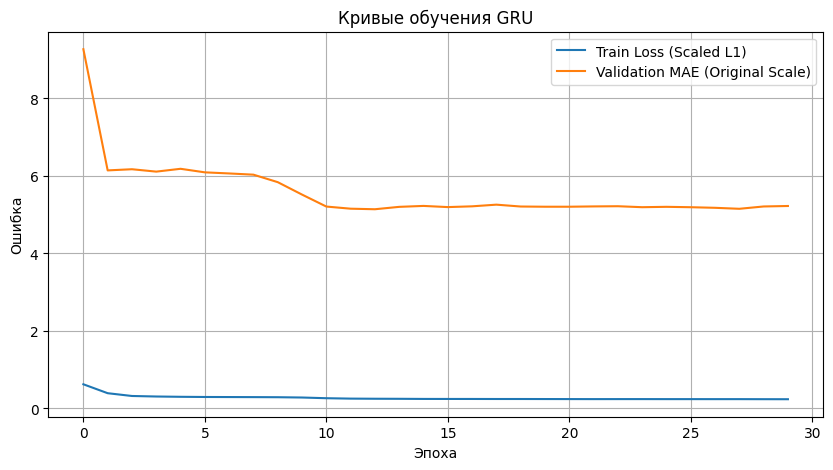

In [13]:
# --- R1: GRU Forecast ---
EPOCHS = 30
LR = 1e-3

model = GRUForecaster(hidden_size=64).to(device)
criterion = nn.L1Loss() # Оптимизируем MAE
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_mae = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x_batch)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_preds, val_trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch).squeeze().cpu().numpy()
            val_preds.extend(preds)
            val_trues.extend(y_batch.numpy())

    # Обратное преобразование масштаба для честного сравнения MAE
    val_preds_inv = target_scaler.inverse_transform(np.array(val_preds).reshape(-1, 1)).flatten()
    val_trues_inv = target_scaler.inverse_transform(np.array(val_trues).reshape(-1, 1)).flatten()

    val_metrics = eval_metrics(val_trues_inv, val_preds_inv)
    val_losses.append(val_metrics['mae'])

    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        best_gru_metrics = val_metrics
        best_val_preds = val_preds_inv

# Сохраняем кривые обучения
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss (Scaled L1)')
plt.plot(val_losses, label='Validation MAE (Original Scale)')
plt.title('Кривые обучения GRU')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

# Логируем R1
runs_results.append({
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12', 'seed': SEED,
    'split_summary': '70/15/15', 'window_size': WINDOW_SIZE, 'horizon': 1,
    'model_summary': 'GRU(hidden=64, layers=1)', 'scaler': 'StandardScaler',
    'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS, 'notes': 'GRU neural network for time series forecasting.',
    'best_val_mae': best_gru_metrics['mae'], 'best_val_rmse': best_gru_metrics['rmse'],
    'best_val_mape': best_gru_metrics['mape']
})

# Сохраняем конфиг
gru_config = {
    'architecture': 'GRU', 'input_size': 1, 'hidden_size': 64, 'num_layers': 1,
    'window_size': WINDOW_SIZE, 'batch_size': BATCH_SIZE, 'learning_rate': LR,
    'seed': SEED, 'scaler': 'StandardScaler'
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)

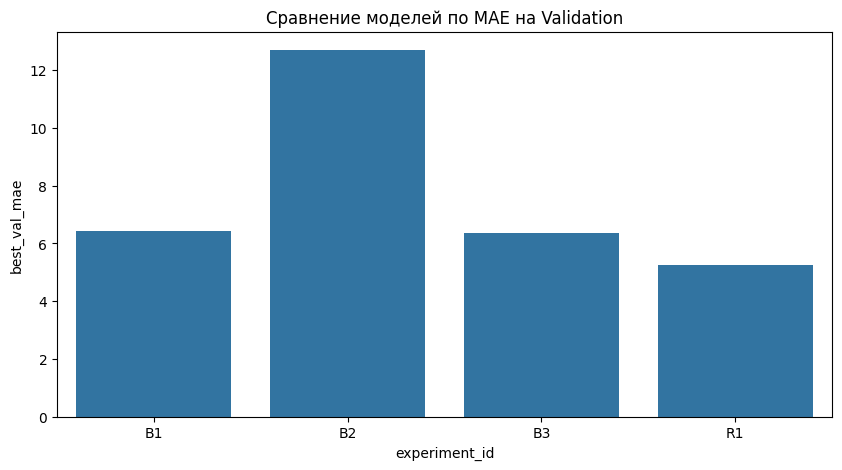

Лучшая модель по Validation: R1
Результаты лучшей модели на TEST:
MAE: 5.7789, RMSE: 7.3588, MAPE: 0.0374


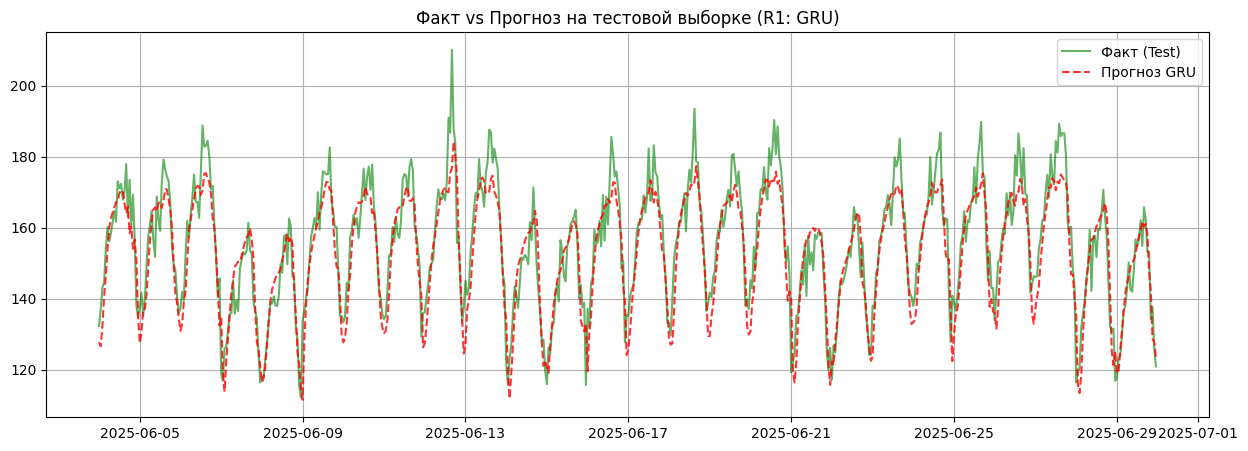

In [11]:
# 1. Сравнение на Validation
results_df = pd.DataFrame(runs_results)
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='experiment_id', y='best_val_mae')
plt.title('Сравнение моделей по MAE на Validation')
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

# Определяем лучшую модель (минимум MAE)
best_exp = results_df.loc[results_df['best_val_mae'].idxmin()]
print(f"Лучшая модель по Validation: {best_exp['experiment_id']}")

# 2. Оценка на Test (ОДИН РАЗ!)
# Загружаем лучшие веса GRU
model.load_state_dict(torch.load('artifacts/best_gru.pt'))
model.eval()

test_preds, test_trues = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = model(x_batch).squeeze().cpu().numpy()
        test_preds.extend(preds)
        test_trues.extend(y_batch.numpy())

test_preds_inv = target_scaler.inverse_transform(np.array(test_preds).reshape(-1, 1)).flatten()
test_trues_inv = target_scaler.inverse_transform(np.array(test_trues).reshape(-1, 1)).flatten()

test_metrics = eval_metrics(test_trues_inv, test_preds_inv)
print("Результаты лучшей модели на TEST:")
print(f"MAE: {test_metrics['mae']:.4f}, RMSE: {test_metrics['rmse']:.4f}, MAPE: {test_metrics['mape']:.4f}")

# Обновляем CSV
results_df.loc[results_df['experiment_id'] == 'R1', ['test_mae', 'test_rmse', 'test_mape']] = [
    test_metrics['mae'], test_metrics['rmse'], test_metrics['mape']
]
results_df.to_csv('artifacts/runs.csv', index=False)

# 3. График факта и прогноза на Test
dates_test = test_df['date'].iloc[WINDOW_SIZE:] # Сдвиг из-за окна
plt.figure(figsize=(15, 5))
plt.plot(dates_test, test_trues_inv, label='Факт (Test)', color='green', alpha=0.6)
plt.plot(dates_test, test_preds_inv, label='Прогноз GRU', color='red', alpha=0.8, linestyle='--')
plt.title('Факт vs Прогноз на тестовой выборке (R1: GRU)')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()